In [12]:
import pandas as pd
import numpy as np

df=pd.read_csv('workout_fitness_tracker_data.csv')
df.head()



,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,1,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued
1,2,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized
2,3,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued
3,4,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral
4,5,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
categorical=['Workout Intensity']

from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
df[['Workout Intensity']]=encoder.fit_transform(df[['Workout Intensity']])

x=df[['Workout Intensity','Workout Duration (mins)','Daily Calories Intake',]]
xscaled=scaler.fit_transform(x)

from sklearn.cluster import KMeans
kmean=KMeans(n_clusters=3,random_state=42)
labels=kmean.fit_predict(xscaled)
df['cluster labels']=labels

In [14]:
df.head()

,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,...,Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout,cluster labels
0,1,39,Male,175,99,Cycling,79,384,112,8850,...,0.0,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued,2
1,2,36,Other,157,112,Cardio,73,612,168,2821,...,0.0,8.6,1.9,2541,73,38.4,28.5,Happy,Energized,2
2,3,25,Female,180,66,HIIT,27,540,133,18898,...,0.0,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued,1
3,4,56,Male,154,89,Cycling,39,672,118,14102,...,2.0,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral,0
4,5,53,Other,194,59,Strength,56,410,170,16518,...,2.0,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized,0


Active
Lazy
Inconsistent

In [15]:
centres=scaler.inverse_transform(kmean.cluster_centers_)
summary=pd.DataFrame(centres,columns=['Workout Intensity','Workout Duration (mins)','Daily Calories Intake'])
print("Cluster summary:\n",summary)

Cluster summary:
    Workout Intensity  Workout Duration (mins)  Daily Calories Intake
0           2.000000                64.603370            2760.432441
1           0.495639                36.889624            2796.488722
2           0.509845                91.680489            2688.856205


label 0=active(biggest numbers for all so this cluster is active)
label 1=lazy
label 2=inconsistent

In [16]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
pca=PCA(n_components=2)
xpca=pca.fit_transform(xscaled)
print("Silhouette score:",silhouette_score(xscaled,labels))

Silhouette score: 0.26259464817607675


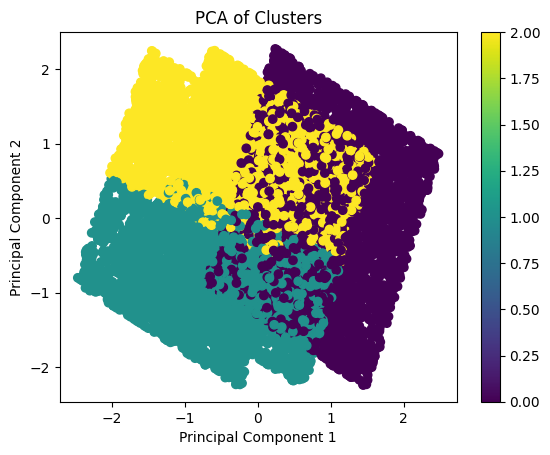

In [17]:
import matplotlib.pyplot as plt
plt.scatter(xpca[:,0],xpca[:,1],c=labels)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Clusters")
plt.colorbar()
plt.show()